# Chronos-2 Benchmarking

| | |
|---|---|
| **Organization** | Amazon Web Services (AWS) |
| **Version** | Chronos-2 (October 2025) |
| **Parameters** | 120M |
| **Input Features** | Target series, optional covariates (past and future known) |

## Key Characteristics

Chronos-2 introduces support for multivariate and covariate-informed forecasting within a single architecture. The model employs a group attention mechanism that alternates between time attention (aggregating information across patches within a single series) and group attention (aggregating information across all series within a group at each patch index). This design enables in-context learning across related series and covariates without requiring task-specific fine-tuning.

The model was trained on a combination of real-world datasets (GiftEvalPretrain) and large-scale synthetic data generated through multivariate structure imposition on univariate base series.

---

**Validation split:** Train on periods 1–36, validate on 37–42 (identical to Notebook 6)  
**Target:** `Revenue cons. (anon)` at subsegment level  
**Runtime:** T4 GPU (Google Colab) — set manually: Runtime → Change runtime type → T4 GPU


---
## 1. Dependencies


In [129]:
# ── Install ──
!pip install -q "chronos-forecasting>=2.0"


In [130]:
# ── Imports ──
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')


GPU available: True
Device: Tesla T4


---
## 2. Configuration


In [131]:
# ── Constants ──
PERIOD_COL = 'Anon Period'
TARGET     = 'Revenue cons. (anon)'
SUBSEG_COL = 'TGL Business Subsegment'
VAL_CUTOFF = 36
HORIZON    = 6

# ── Paths ──
DATA_PATH = '/content/drive/MyDrive/Coding/data/features/training_subsegment_fs.parquet'
VAL_PATH  = '/content/drive/MyDrive/Coding/data/features/validation_subsegment_fs.parquet'
OUTPUT_DIR = Path('/content/drive/MyDrive/Coding/data/predictions/')


---
## 3. Function Definitions


In [132]:
def filter_leaky_features(feature_cols, orders_strategy='drop'):
    """Drop features that would leak future order/ASP information."""
    if orders_strategy == 'drop':
        blocked = ('ord', 'orders', 'asp')
        return [c for c in feature_cols
                if not any(tok in c.lower() for tok in blocked)]
    return list(feature_cols)


In [133]:
def evaluate(results: dict, label: str) -> dict:
    """Compute RMSE, wMAPE, and R² across all subsegment forecasts."""
    all_true, all_pred = [], []
    for seg, preds in results.items():
        actuals = (val_df[val_df[SUBSEG_COL] == seg]
                   .sort_values(PERIOD_COL)
                   .dropna(subset=[TARGET])[TARGET].values)
        n = min(len(actuals), len(preds))
        all_true.extend(actuals[:n])
        all_pred.extend(preds[:n])
    y, yh = np.array(all_true), np.array(all_pred)
    rmse  = np.sqrt(mean_squared_error(y, yh))
    wmape = np.sum(np.abs(y - yh)) / np.sum(np.abs(y)) * 100
    r2    = r2_score(y, yh)
    print(f'{label} — RMSE: {rmse:,.0f} | wMAPE: {wmape:.1f}% | R²: {r2:.4f}')
    return {'Model': label, 'RMSE': rmse, 'wMAPE': wmape, 'R2': r2}


In [134]:
def plot_forecast_area(train_full, agg_preds, model_name,
                       target=TARGET, period_col=PERIOD_COL, figsize=(14, 5)):
    """Area chart: actuals (train split) vs. validation-period predictions."""
    actuals     = train_full.groupby(period_col)[target].sum().sort_index()
    periods     = actuals.index.tolist()
    actual_vals = actuals.values

    val_periods = sorted(agg_preds.keys())
    pred_vals   = [agg_preds[p] for p in val_periods]
    cutoff_x    = val_periods[0] - 0.5

    fig, ax = plt.subplots(figsize=figsize)
    ax.fill_between(periods, actual_vals, alpha=0.80,
                    color='#378ADD', label='Actual Revenue')
    ax.plot(periods, actual_vals, color='#185FA5', linewidth=0.6)
    ax.fill_between(val_periods, pred_vals, alpha=0.85,
                    color='#D85A30', label=f'{model_name} — Validation')
    ax.plot(val_periods, pred_vals, color='#993C1D',
            linewidth=1.5, marker='o', markersize=5, zorder=5)
    ax.axvline(cutoff_x, color='white', linewidth=1.8, linestyle='--', alpha=0.8)
    ax.text(cutoff_x + 0.15, ax.get_ylim()[1] * 0.96,
            'validation →', fontsize=9, color='white', va='top', alpha=0.9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.set_xlabel('Period', fontsize=11)
    ax.set_ylabel('Total Revenue', fontsize=11)
    ax.set_title(
        f'Validation Forecast — {model_name}  '
        f'(periods {val_periods[0]}–{val_periods[-1]})',
        fontsize=12)
    ax.legend(fontsize=10, framealpha=0.3, loc='upper left')
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    plt.tight_layout()
    plt.show()


In [135]:
def plot_forecast_comparison(
    train_df, submission_df, period_col, target_col, best_model_name, output_dir,
    forecast_col='Revenue_Predicted',
    hist_periods_label='Historical Revenue (periods 1–42)',
    forecast_periods_label=None,
):
    """Area chart: full historical series vs. blind forecast (periods 43–48)."""
    if forecast_periods_label is None:
        forecast_periods_label = f"{best_model_name} Forecast (periods 43–48)"

    hist = train_df.groupby(period_col)[target_col].sum()
    fore = submission_df.groupby(period_col)[forecast_col].sum()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(hist.index, hist.values, alpha=0.75,
                    color='#378ADD', label=hist_periods_label)
    ax.plot(hist.index, hist.values, color='#185FA5', linewidth=0.8)
    ax.fill_between(fore.index, fore.values, alpha=0.80,
                    color='#D85A30', label=forecast_periods_label)
    ax.plot(fore.index, fore.values, color='#993C1D',
            linewidth=2, marker='o', markersize=6, zorder=5)
    for period, val in fore.items():
        ax.annotate(f'{val/1e6:.0f}M', xy=(period, val), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=8.5, color='#993C1D', fontweight='500')
    ax.axvline(hist.index.max() + 0.5, color='#888780',
               linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(hist.index.max() + 0.7, ax.get_ylim()[1] * 0.97, 'forecast →',
            fontsize=9, color='#888780', va='top')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.set_xlabel('Period', fontsize=11)
    ax.set_ylabel('Total Revenue', fontsize=11)
    ax.set_title(
        f'{best_model_name} — Historical Revenue & Forecast  '
        f'(Subsegment level, all series aggregated)',
        fontsize=12, pad=12,
    )
    ax.legend(fontsize=10, loc='upper left')
    ax.set_xlim(1, max(fore.index) + 1)
    sns.despine()
    plt.tight_layout()

    output_path = output_dir / f'forecast_plot_{best_model_name.lower()}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    return output_path


---
## 4. Data Loading


In [136]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [137]:
# ── Load training data & split ──
full_train = pd.read_parquet(DATA_PATH)
train_df   = full_train[full_train[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df     = full_train[full_train[PERIOD_COL] >  VAL_CUTOFF].copy()

print(f'Full train:      {full_train.shape}')
print(f'Train (1–36):    {train_df.shape}')
print(f'Val   (37–42):   {val_df.shape}')


Full train:      (4237, 110)
Train (1–36):    (3524, 110)
Val   (37–42):   (713, 110)


In [138]:
# ── Feature engineering: build clean feature list & subsegment list ──
exclude = [TARGET, PERIOD_COL, SUBSEG_COL,
           'TGL Biz Desc', 'TGL Business Unit',
           'TGL Business Segment', 'Orders cons. (anon)']
           
feature_cols = [c for c in full_train.columns if c not in exclude]
feature_cols = filter_leaky_features(feature_cols, orders_strategy='drop')

subsegments = sorted(
    train_df.dropna(subset=[TARGET])
    .groupby(SUBSEG_COL, observed=True)
    .size()
    .pipe(lambda s: s[s >= 1].index)
    .tolist()
)

print(f'Feature cols after leaky filter: {len(feature_cols)}')
print(f'Subsegments:                     {len(subsegments)}')

# Note: val_blind features are not used as covariates here.
# If val_blind is used as future covariates in the future, apply:
# val_feature_cols = filter_leaky_features([c for c in val_blind.columns if c not in exclude])


Feature cols after leaky filter: 53
Subsegments:                     119


---
## 5. Model Loading


In [139]:
from chronos import Chronos2Pipeline

chronos2_pipeline = Chronos2Pipeline.from_pretrained(
    'amazon/chronos-2',
    device_map='cuda' if torch.cuda.is_available() else 'cpu'
)
print('Chronos-2 loaded.')


Chronos-2 loaded.


---
## 6. Validation Forecasting (Periods 37–42)


In [140]:
# ── Run Chronos-2 on train split (periods 1–36) → forecast 37–42 ──
chronos2_results, chronos2_errors = {}, []

for i, seg in enumerate(subsegments):
    train_s = train_df[train_df[SUBSEG_COL] == seg].sort_values(PERIOD_COL).dropna(subset=[TARGET])
    val_s   = val_df[val_df[SUBSEG_COL] == seg].sort_values(PERIOD_COL).dropna(subset=[TARGET])
    if len(train_s) < 3 or len(val_s) == 0:
        continue
    try:
        ctx = train_s[[PERIOD_COL, TARGET] + feature_cols].copy()
        ctx['timestamp'] = ctx[PERIOD_COL].apply(
            lambda p: pd.Timestamp('2022-01-01') + pd.DateOffset(months=int(p) - 1)
        )
        ctx = ctx.drop(columns=[PERIOD_COL]).rename(columns={TARGET: 'target'})
        ctx = ctx.set_index('timestamp')
        # Extend to VAL_CUTOFF to fill gaps and ensure regular frequency
        max_ctx_ts = pd.Timestamp('2022-01-01') + pd.DateOffset(months=VAL_CUTOFF - 1)
        full_idx = pd.date_range(ctx.index.min(), max_ctx_ts, freq='MS')
        ctx = ctx.reindex(full_idx).fillna(0)
        ctx['id'] = seg  # re-set id after fillna
        ctx = ctx.reset_index().rename(columns={'index': 'timestamp'})
        pred_df = chronos2_pipeline.predict_df(
            ctx,
            prediction_length=len(val_s),
            quantile_levels=[0.5],
            id_column='id',
            timestamp_column='timestamp',
            target='target',
        )
        chronos2_results[seg] = pred_df['0.5'].values
    except Exception as e:
        chronos2_errors.append((seg, str(e)))
    if (i + 1) % 25 == 0:
        print(f'{i+1}/{len(subsegments)}')

skipped = [seg for seg in subsegments if seg not in chronos2_results
           and not any(seg == e[0] for e in chronos2_errors)]
print(f'Results: {len(chronos2_results)}/{len(subsegments)} | Errors: {len(chronos2_errors)} | Skipped: {len(skipped)}')
if skipped:
    print('Skipped (insufficient history):', skipped)
if chronos2_errors:
    for seg, err in chronos2_errors:
        print(f'  {seg}: {err}')


25/119
50/119
75/119
Results: 107/119 | Errors: 0 | Skipped: 12
Skipped (insufficient history): ['SSI02710', 'SSI0278604', 'SSI0278624', 'SSI0278630', 'SSI02796', 'SSI02798', 'SSI02799', 'SSI03782', 'SSI04783', 'SSI0478499', 'SSI07098', 'SSI07099']


In [171]:
# ── Results tracker & evaluation ──
all_metrics = []

metrics_chronos2 = evaluate(chronos2_results, 'Chronos-2')
all_metrics.append(metrics_chronos2)


Chronos-2 — RMSE: 8,349,693 | wMAPE: 9.9% | R²: 0.9850


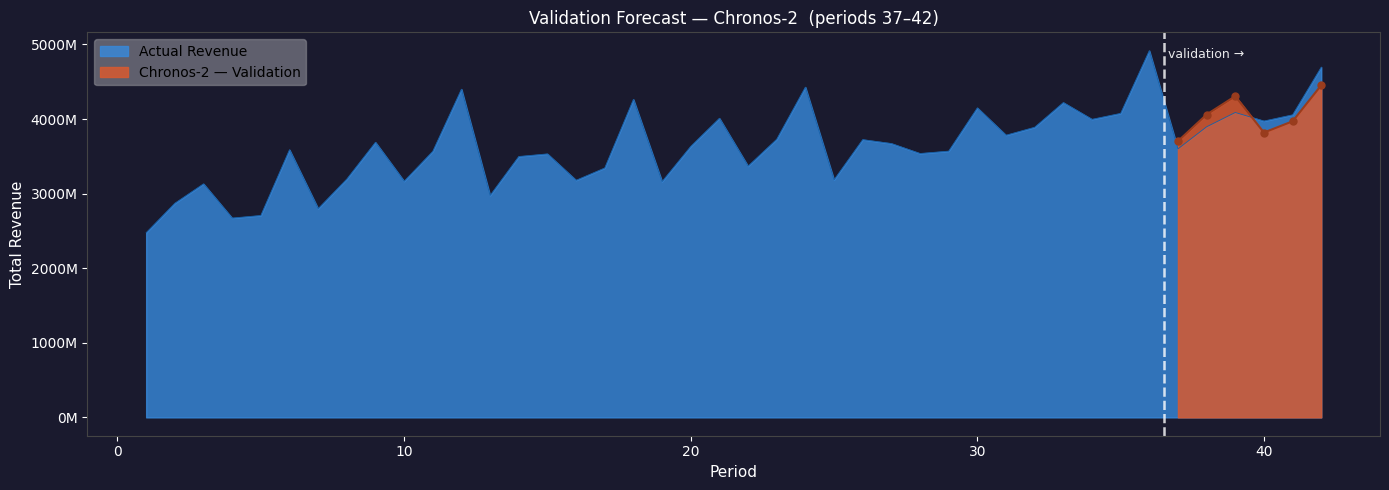

In [142]:
# ── Aggregate predictions by period & plot ──
agg_preds = {}
for t in range(HORIZON):
    period = VAL_CUTOFF + 1 + t   # 37 … 42
    agg_preds[period] = sum(
        preds[t] for preds in chronos2_results.values() if len(preds) > t
    )

plot_forecast_area(full_train, agg_preds, 'Chronos-2')


---
## 7. Blind Forecast (Periods 43–48)


In [157]:
# ── Load hold-out feature set ──
val_blind = pd.read_parquet(VAL_PATH)

# Apply same leaky-feature filter as full_train
val_feature_cols = filter_leaky_features(
    [c for c in val_blind.columns if c not in exclude],
    orders_strategy='drop'
)
assert set(val_feature_cols) == set(feature_cols), \
    f'Feature mismatch: train={len(feature_cols)}, val={len(val_feature_cols)}'

print(f'Hold-out set: {val_blind.shape}')
print(f'Feature cols after leaky filter: {len(val_feature_cols)}')

TEST_CUTOFF = full_train[PERIOD_COL].max()  # = 42
test_subsegments = sorted(val_blind[SUBSEG_COL].unique())
print(f'Subsegments to forecast: {len(test_subsegments)} | Test cutoff: {TEST_CUTOFF}')


Hold-out set: (715, 110)
Feature cols after leaky filter: 53
Subsegments to forecast: 124 | Test cutoff: 42


In [176]:
# ── Re-run Chronos-2 on full training context (1–42) + future covariates (43–48) ──
USE_FUTURE_COVARIATES = False  # set to True to include val_blind features as future context
chronos2_test_results, chronos2_test_errors = {}, []

for i, seg in enumerate(test_subsegments):
    train_s = full_train[full_train[SUBSEG_COL] == seg].sort_values(PERIOD_COL).dropna(subset=[TARGET])
    val_s   = val_blind[val_blind[SUBSEG_COL] == seg].sort_values(PERIOD_COL)

    if len(train_s) < 3:
        chronos2_test_errors.append((seg, 'insufficient history'))
        continue
    try:
        # Historical context (periods 1–42): target + past covariates
        hist = train_s[[PERIOD_COL, TARGET] + feature_cols].copy()
        hist['timestamp'] = hist[PERIOD_COL].apply(
            lambda p: pd.Timestamp('2022-01-01') + pd.DateOffset(months=int(p) - 1)
        )
        hist = hist.drop(columns=[PERIOD_COL]).rename(columns={TARGET: 'target'})
        hist = hist.set_index('timestamp')
        # Extend to TEST_CUTOFF to avoid gap with future covariates
        max_hist_ts = pd.Timestamp('2022-01-01') + pd.DateOffset(months=TEST_CUTOFF - 1)
        full_idx = pd.date_range(hist.index.min(), max_hist_ts, freq='MS')
        hist = hist.reindex(full_idx).fillna(0)
        hist['id'] = seg  # re-set id after fillna
        hist = hist.reset_index().rename(columns={'index': 'timestamp'})
  
        # Future context (periods 43–48): known covariates, target = NaN
        if USE_FUTURE_COVARIATES and len(val_s) > 0:
            
            fut = val_s[val_feature_cols].copy()
            fut['timestamp'] = val_s[PERIOD_COL].apply(
                lambda p: pd.Timestamp('2022-01-01') + pd.DateOffset(months=int(p) - 1)
            ).values
            fut['target'] = float('nan')
            fut['id'] = seg
            fut = fut[hist.columns]  # align column order to hist
            ctx = pd.concat([hist, fut], ignore_index=True)

        else:
            ctx = hist


        pred_df = chronos2_pipeline.predict_df(
            ctx,
            prediction_length=HORIZON,
            quantile_levels=[0.5],
            id_column='id',
            timestamp_column='timestamp',
            target='target',
        )
        chronos2_test_results[seg] = pred_df['0.5'].values
    except Exception as e:
        chronos2_test_errors.append((seg, str(e)))
    if (i + 1) % 25 == 0:
        print(f'{i+1}/{len(test_subsegments)}')

print(f'Done. Results: {len(chronos2_test_results)} | Errors: {len(chronos2_test_errors)}')
if chronos2_test_errors:
    print('Errors:')
    for seg, err in chronos2_test_errors:
        print(f'  {seg}: {err}')

25/124
50/124
75/124
100/124
Done. Results: 122 | Errors: 2
Errors:
  SSI0278218: insufficient history
  SSI0278468: insufficient history


In [177]:
# ── Build submission DataFrame ──
rows = [
    {SUBSEG_COL: seg, PERIOD_COL: TEST_CUTOFF + 1 + t, 'Revenue_Predicted': float(p)}
    for seg, preds in chronos2_test_results.items()
    for t, p in enumerate(preds)
]
submission_df = pd.DataFrame(rows)
submission_df


,TGL Business Subsegment,Anon Period,Revenue_Predicted
0,SSI02710,43,2.685691e+03
1,SSI02710,44,2.521914e+03
2,SSI02710,45,2.711039e+03
3,SSI02710,46,2.402523e+03
4,SSI02710,47,1.646867e+03
...,...,...,...
727,SSI0708310,44,7.804433e+06
728,SSI0708310,45,7.914232e+06
729,SSI0708310,46,7.507940e+06
730,SSI0708310,47,8.114928e+06


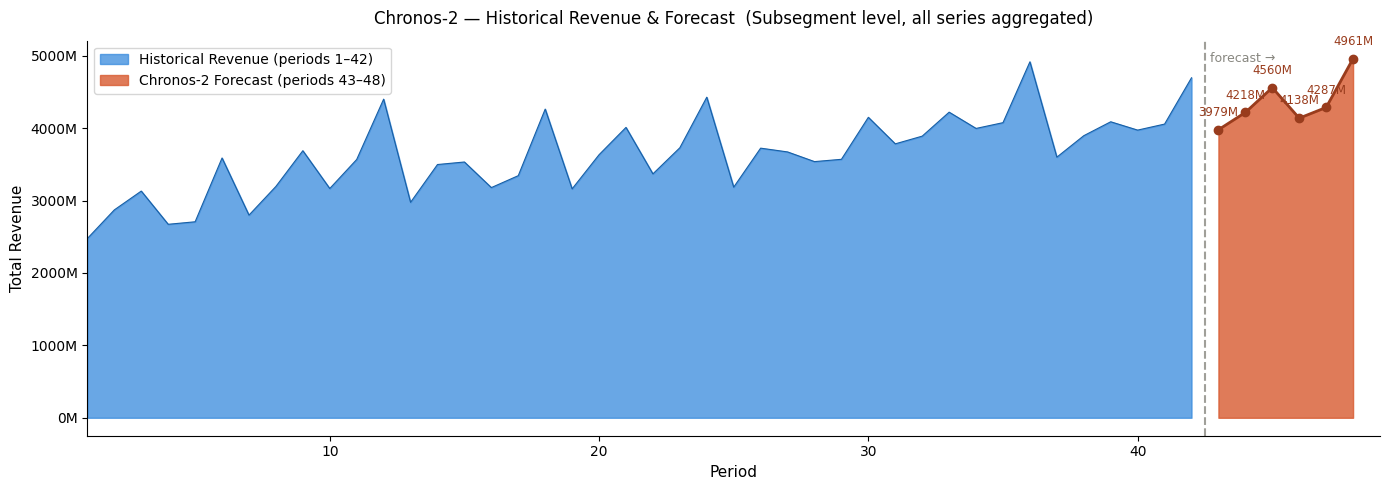

PosixPath('/content/drive/MyDrive/Coding/data/predictions/forecast_plot_chronos-2.png')

In [178]:
# ── Plot blind forecast ──
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plot_forecast_comparison(
    train_df=full_train,
    submission_df=submission_df,
    period_col=PERIOD_COL,
    target_col=TARGET,
    best_model_name='Chronos-2',
    output_dir=OUTPUT_DIR,
)
